In [ ]:
import os
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
import tensorflow as tf
print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2.16.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU ready")

GPU ready


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = 'dataset/train'
VAL_DIR   = 'dataset/val'
TEST_DIR  = 'dataset/test'
IMG_SIZE  = (48, 48)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)
classes = list(train_generator.class_indices.keys())

print("Train batches:", len(train_generator))
print("Val batches:  ", len(val_generator))
print("Test batches: ", len(test_generator))
print("Classes:", classes)
print("NUM_CLASSES:", NUM_CLASSES)

Found 26909 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train batches: 841
Val batches:   221
Test batches:  60
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES: 7


In [ ]:
from keras import Input
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_baseline(num_classes):
    model = Sequential([
        Input(shape=(48, 48, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline = build_baseline(NUM_CLASSES)
baseline.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,759 (5.02 MB)

 Trainable params: 1,314,759 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os

for split in ['train', 'val', 'test']:
    path = f'dataset/{split}'
    if os.path.exists(path):
        total = sum(len(files) for _, _, files in os.walk(path))
        classes = [d for d in os.listdir(path) if os.path.isdir(f'{path}/{d}')]
        print(f"{split}: {total} files, {len(classes)} classes")
    else:
        print(f"{split}: NOT FOUND")

train: 26909 files, 7 classes
val: 7073 files, 7 classes
test: 1900 files, 7 classes


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = 'dataset/train'
VAL_DIR   = 'dataset/val'
TEST_DIR  = 'dataset/test'
IMG_SIZE  = (48, 48)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Train batches:", len(train_generator))
print("Val batches:  ", len(val_generator))
print("Test batches: ", len(test_generator))
print("Classes:", train_generator.class_indices)

Found 26909 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train batches: 841
Val batches:   221
Test batches:  60
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
base_dir  = '/home/pukar/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')
test_dir  = os.path.join(base_dir, 'test')

classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])

NUM_CLASSES = len(classes)
IMG_SIZE    = (48, 48)
BATCH_SIZE  = 64

print('Classes     :', classes)
print('NUM_CLASSES :', NUM_CLASSES)

Classes     : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES : 7


In [ ]:
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
corrupted_files  = []
checked          = 0

for split_dir in [train_dir, val_dir, test_dir]:
    for cls in classes:
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            checked += 1

            if checked % 1000 == 0:
                print(f'Checked {checked} files so far ...')

            if not fname.lower().endswith(valid_extensions):
                corrupted_files.append(fpath)
                continue

            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                corrupted_files.append(fpath)

print(f'Finished checking {checked} total files')
print(f'Corrupted or invalid files found : {len(corrupted_files)}')

for fpath in corrupted_files:
    os.remove(fpath)
    print(f'Removed : {fpath}')

print(f'Total files removed : {len(corrupted_files)}')

Checked 1000 files so far ...
Checked 2000 files so far ...
Checked 3000 files so far ...
Checked 4000 files so far ...
Checked 5000 files so far ...
Checked 6000 files so far ...
Checked 7000 files so far ...
Checked 8000 files so far ...
Checked 9000 files so far ...
Checked 10000 files so far ...
Checked 11000 files so far ...
Checked 12000 files so far ...
Checked 13000 files so far ...
Checked 14000 files so far ...
Checked 15000 files so far ...
Checked 16000 files so far ...
Checked 17000 files so far ...
Checked 18000 files so far ...
Checked 19000 files so far ...
Checked 20000 files so far ...
Checked 21000 files so far ...
Checked 22000 files so far ...
Checked 23000 files so far ...
Checked 24000 files so far ...
Checked 25000 files so far ...
Checked 26000 files so far ...
Checked 27000 files so far ...
Checked 28000 files so far ...
Checked 29000 files so far ...
Checked 30000 files so far ...
Checked 31000 files so far ...
Checked 32000 files so far ...
Checked 33000 fil

In [ ]:
def count_images(directory, classes):
    """
    Count the number of images in each class subdirectory.

    Parameters
    ----------
    directory : str
        Path to the split directory.
    classes : list
        List of class folder names.

    Returns
    -------
    dict
        Dictionary mapping class name to image count.
    """
    return {
        cls: len([
            f for f in os.listdir(os.path.join(directory, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for cls in classes
    }

train_counts = count_images(train_dir, classes)
val_counts   = count_images(val_dir,   classes)
test_counts  = count_images(test_dir,  classes)

print('Training Distribution:')
for cls, count in train_counts.items():
    print(f'  {cls:<15} : {count}')

print('\nValidation Distribution:')
for cls, count in val_counts.items():
    print(f'  {cls:<15} : {count}')

print('\nTest Distribution:')
for cls, count in test_counts.items():
    print(f'  {cls:<15} : {count}')

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

print('\nDataset Summary')
print(f'  Total Train      : {total_train}')
print(f'  Total Validation : {total_val}')
print(f'  Total Test       : {total_test}')
print(f'  Grand Total      : {total_train + total_val + total_test}')

Training Distribution:
  angry           : 3723
  disgust         : 329
  fear            : 3796
  happy           : 6857
  neutral         : 4675
  sad             : 4631
  surprise        : 2898

Validation Distribution:
  angry           : 960
  disgust         : 111
  fear            : 1018
  happy           : 1825
  neutral         : 1216
  sad             : 1139
  surprise        : 797

Test Distribution:
  angry           : 300
  disgust         : 100
  fear            : 300
  happy           : 300
  neutral         : 300
  sad             : 300
  surprise        : 300

Dataset Summary
  Total Train      : 26909
  Total Validation : 7066
  Total Test       : 1900
  Grand Total      : 35875


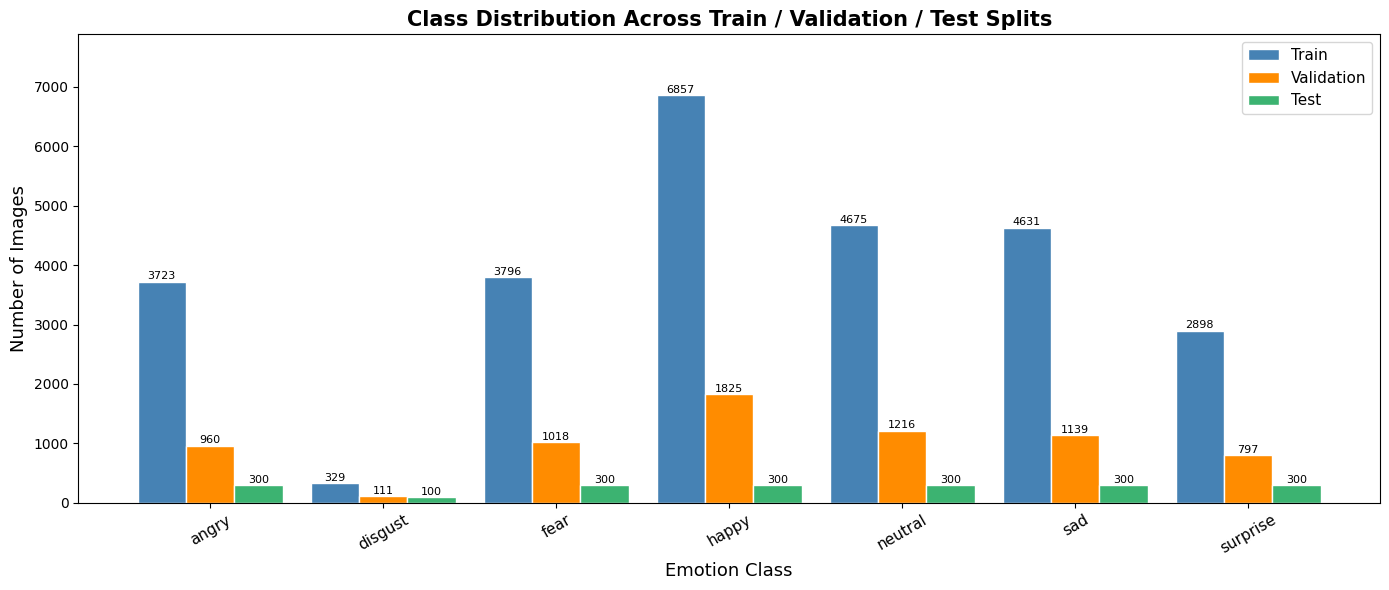

In [ ]:
x     = np.arange(len(classes))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))

bars_train = ax.bar(x - width, list(train_counts.values()),
                    width, label='Train',      color='steelblue',      edgecolor='white')
bars_val   = ax.bar(x,          list(val_counts.values()),
                    width, label='Validation', color='darkorange',     edgecolor='white')
bars_test  = ax.bar(x + width,  list(test_counts.values()),
                    width, label='Test',       color='mediumseagreen', edgecolor='white')

for bar_group in [bars_train, bars_val, bars_test]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height + 5,
                str(int(height)), ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Emotion Class',    fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('Class Distribution Across Train / Validation / Test Splits',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(train_counts.values()) * 1.15)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

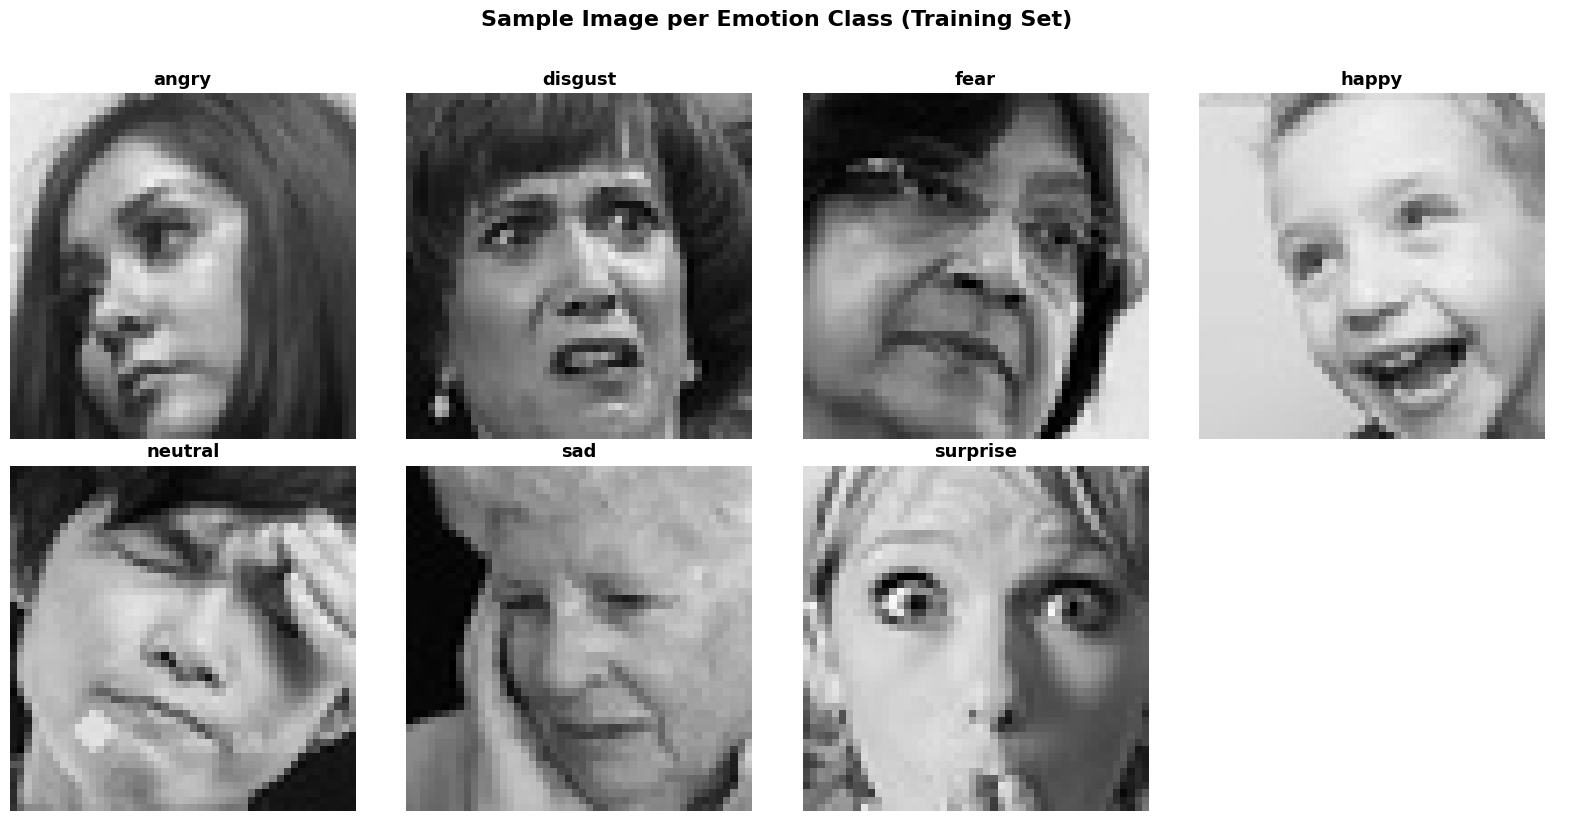

In [ ]:
n_classes = len(classes)
n_cols    = 4
n_rows    = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes      = axes.flatten()

for i, cls in enumerate(classes):
    cls_path    = os.path.join(train_dir, cls)
    image_files = [f for f in os.listdir(cls_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = Image.open(os.path.join(cls_path, image_files[0])).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].axis('off')

for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Image per Emotion Class (Training Set)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

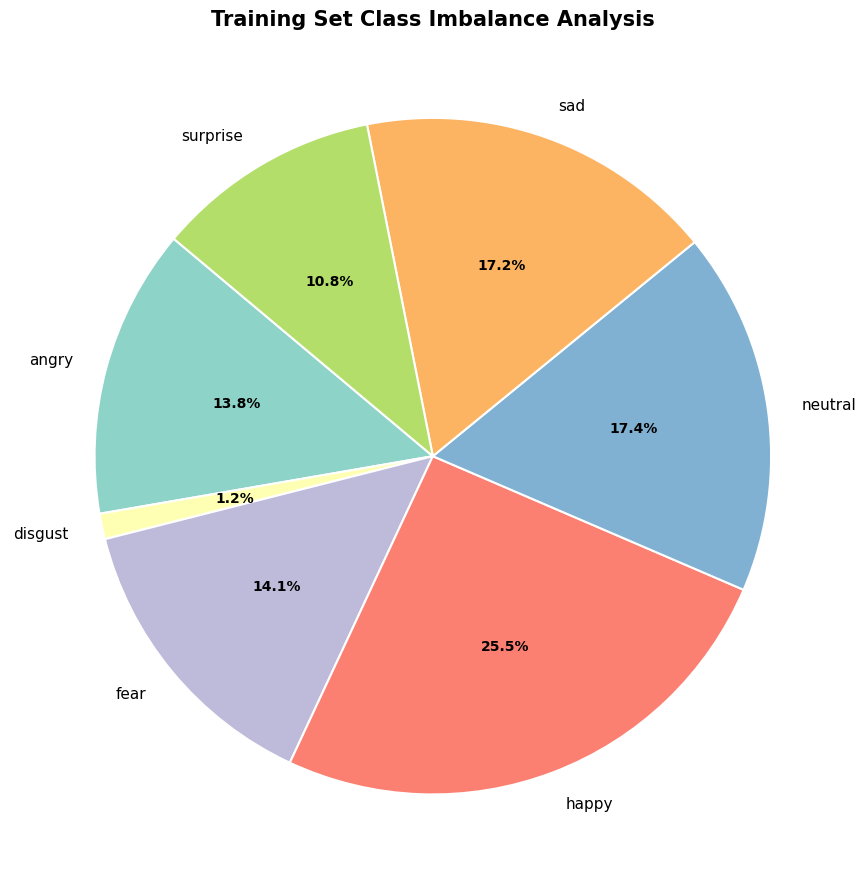

Class Imbalance Report
  Largest class   : happy (6857 images)
  Smallest class  : disgust (329 images)
  Imbalance ratio : 20.84x


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    list(train_counts.values()),
    labels=classes,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:n_classes],
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Training Set Class Imbalance Analysis',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('class_imbalance_pie.png', dpi=150)
plt.show()

max_class = max(train_counts, key=train_counts.get)
min_class = min(train_counts, key=train_counts.get)
ratio     = train_counts[max_class] / train_counts[min_class]

print('Class Imbalance Report')
print(f'  Largest class   : {max_class} ({train_counts[max_class]} images)')
print(f'  Smallest class  : {min_class} ({train_counts[min_class]} images)')
print(f'  Imbalance ratio : {ratio:.2f}x')

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_generator = eval_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

print(f'Train      : {train_generator.samples}')
print(f'Validation : {val_generator.samples}')
print(f'Test       : {test_generator.samples}')

Found 26909 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train      : 26909
Validation : 7066
Test       : 1900


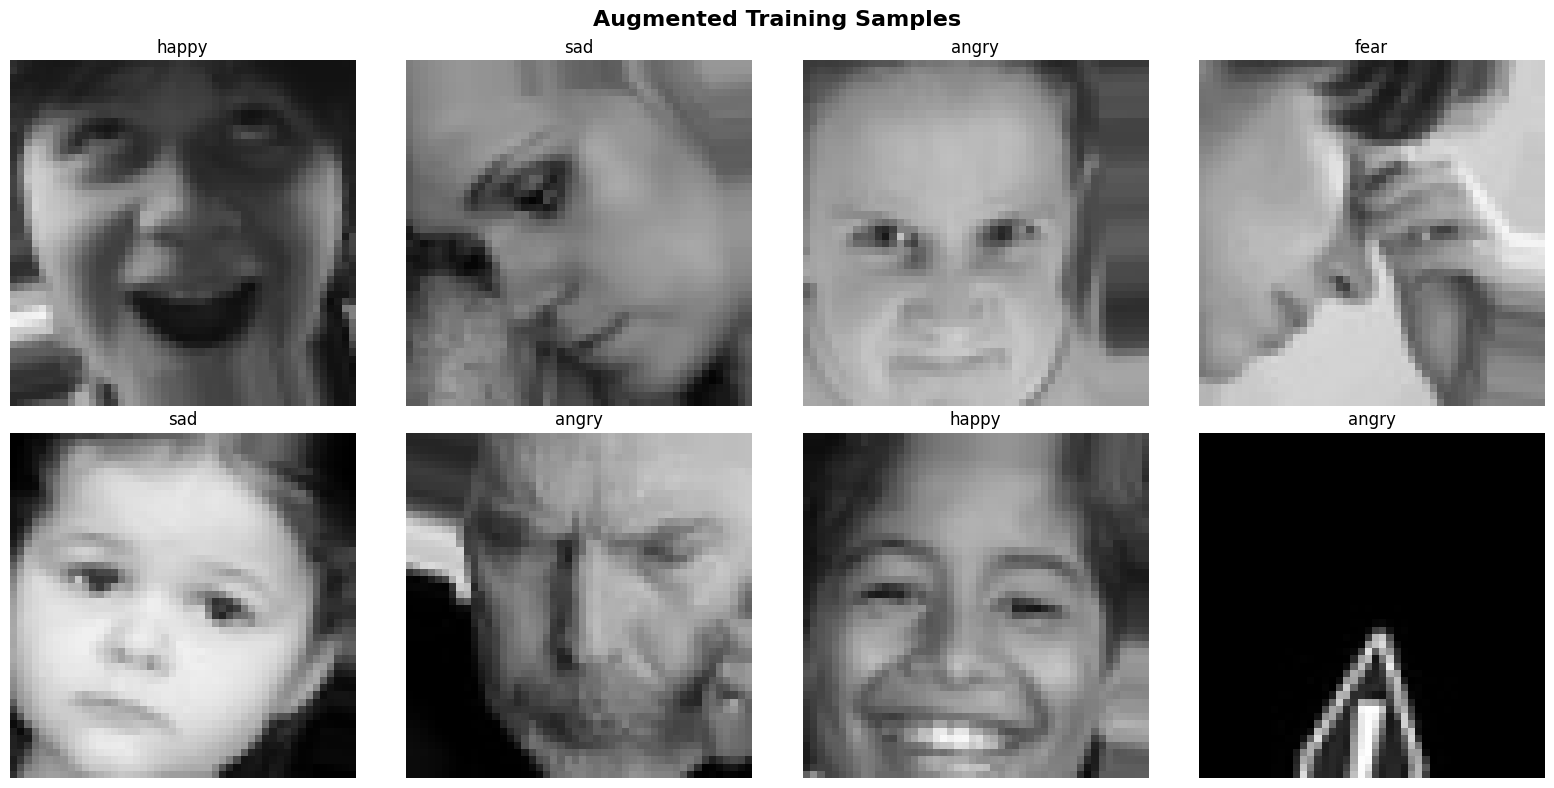

In [ ]:
sample_imgs, sample_lbls = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.set_title(classes[np.argmax(sample_lbls[i])], fontsize=12)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

In [ ]:
def plot_history(history, title):
    """Plot training and validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, generator, classes, title):
    """Evaluate model and display confusion matrix and classification report."""
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = generator.classes
    acc          = accuracy_score(y_true, y_pred)

    print(f'\nEvaluation Report : {title}')
    print(f'Test Accuracy     : {acc * 100:.2f}%')
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=10)
    plt.yticks(tick_marks, classes, fontsize=10)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black',
                 fontsize=9)
    plt.ylabel('True Label',      fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()

    return y_true, y_pred, acc

print('Helper functions defined successfully')

Helper functions defined successfully


In [ ]:
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Fix CUDA memory fragmentation — add this BEFORE building any model
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found: {gpus}")
    except RuntimeError as e:
        print(e)

def build_baseline(num_classes):
    model = Sequential([
        Input(shape=(48, 48, 3)),          # ← explicit Input layer (Keras 3 style)
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline = build_baseline(NUM_CLASSES)
baseline.summary()

GPU(s) found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,759 (5.02 MB)

 Trainable params: 1,314,759 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1777800802.049537   10088 service.cc:145] XLA service 0x7f76a400d640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777800802.050163   10088 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1777800815.728324   10276 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_780', 436 bytes spill stores, 436 bytes spill loads

I0000 00:00:1777800815.940052   10270 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_780', 428 bytes spill stores, 428 bytes spill loads

I0000 00:00:1777800829.509649   10088 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/421 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.2507 - loss: 1.8061

I0000 00:00:1777800859.405858   10420 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_780', 4 bytes spill stores, 4 bytes spill loads



421/421 ━━━━━━━━━━━━━━━━━━━━ 79s 118ms/step - accuracy: 0.2779 - loss: 1.7544 - val_accuracy: 0.3755 - val_loss: 1.6202 - learning_rate: 0.0010
Epoch 2/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.3755 - loss: 1.5881 - val_accuracy: 0.4468 - val_loss: 1.4265 - learning_rate: 0.0010
Epoch 3/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.4357 - loss: 1.4507 - val_accuracy: 0.4891 - val_loss: 1.3276 - learning_rate: 0.0010
Epoch 4/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.4711 - loss: 1.3678 - val_accuracy: 0.5174 - val_loss: 1.2740 - learning_rate: 0.0010
Epoch 5/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.4980 - loss: 1.3100 - val_accuracy: 0.5323 - val_loss: 1.2293 - learning_rate: 0.0010
Epoch 6/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.5176 - loss: 1.2616 - val_accuracy: 0.5314 - val_loss: 1.2422 - learning_rate: 0.0010
Epoch 7/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.5298 - loss: 1.23

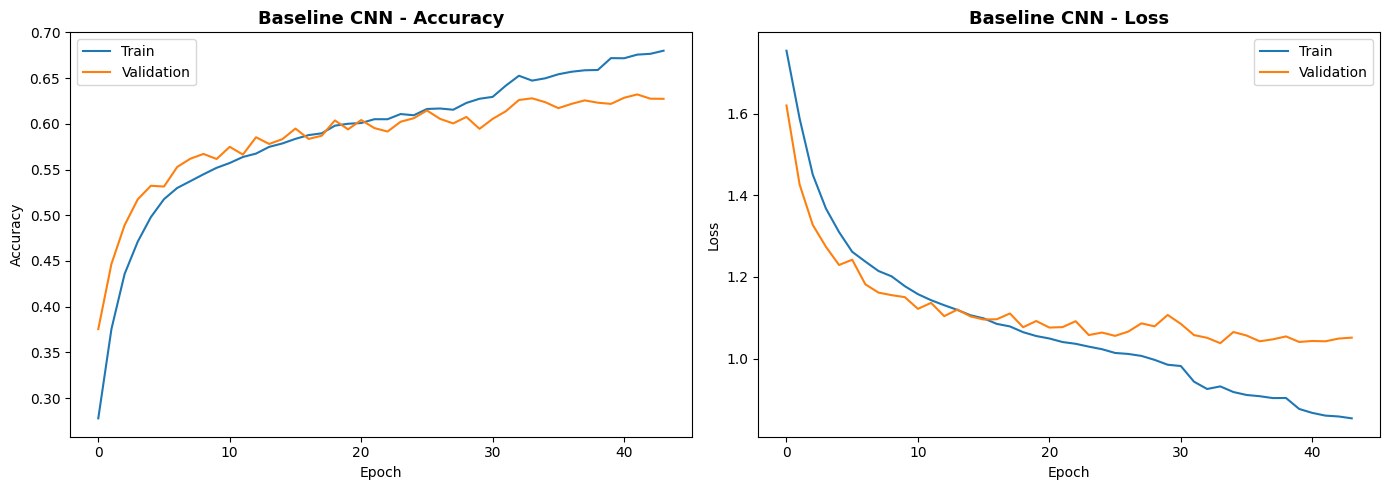

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step

Evaluation Report : Baseline CNN
Test Accuracy     : 56.95%
              precision    recall  f1-score   support

       angry       0.52      0.50      0.51       300
     disgust       0.89      0.34      0.49       100
        fear       0.43      0.30      0.35       300
       happy       0.71      0.84      0.77       300
     neutral       0.47      0.69      0.56       300
         sad       0.44      0.43      0.44       300
    surprise       0.79      0.74      0.76       300

    accuracy                           0.57      1900
   macro avg       0.61      0.55      0.55      1900
weighted avg       0.58      0.57      0.56      1900



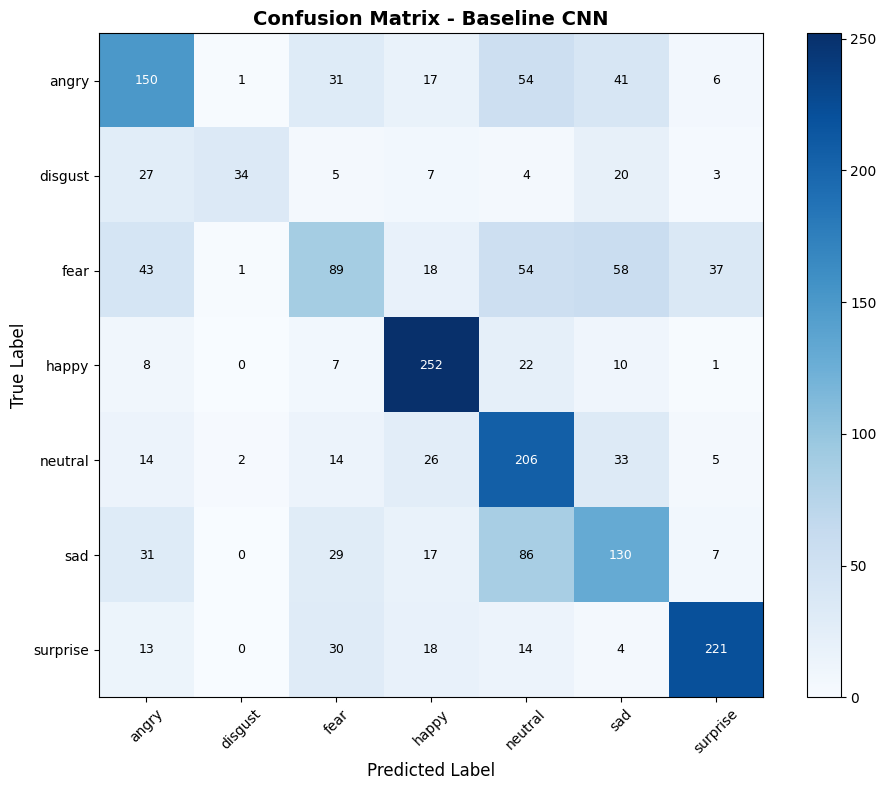

Baseline model saved


In [ ]:
baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, min_lr=1e-6, verbose=1)
]

start_time       = time.time()
history_baseline = baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)
baseline_time = time.time() - start_time

print(f'Baseline training time : {baseline_time:.1f} seconds')
plot_history(history_baseline, 'Baseline CNN')
y_true_b, y_pred_b, acc_b = evaluate_model(
    baseline, test_generator, classes, 'Baseline CNN')
baseline.save('baseline_cnn.h5')
print('Baseline model saved')

In [ ]:
def build_deeper(num_classes):
    """
    Build deeper CNN with 4 convolutional blocks,
    batch normalization and dropout regularization.

    Parameters
    ----------
    num_classes : int
        Number of output emotion classes.

    Returns
    -------
    model : keras Sequential model
    """
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(48, 48, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper = build_deeper(NUM_CLASSES)
deeper.summary()

In [ ]:
deeper.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time     = time.time()
history_deeper = deeper.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks
)
deeper_time = time.time() - start_time

print(f'Deeper CNN training time : {deeper_time:.1f} seconds')
plot_history(history_deeper, 'Deeper CNN Adam')
y_true_d, y_pred_d, acc_d = evaluate_model(
    deeper, test_generator, classes, 'Deeper CNN Adam')
deeper.save('deeper_cnn_adam.h5')
print('Deeper CNN model saved')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN')
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper CNN')
axes[0].set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN')
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper CNN')
axes[1].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150)
plt.show()

In [ ]:
deeper_sgd = build_deeper(NUM_CLASSES)
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time  = time.time()
history_sgd = deeper_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks
)
sgd_time = time.time() - start_time

print(f'SGD training time : {sgd_time:.1f} seconds')
plot_history(history_sgd, 'Deeper CNN SGD')
y_true_s, y_pred_s, acc_s = evaluate_model(
    deeper_sgd, test_generator, classes, 'Deeper CNN SGD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deeper.history['val_accuracy'], label='Adam')
axes[0].plot(history_sgd.history['val_accuracy'],    label='SGD')
axes[0].set_title('Validation Accuracy : Adam vs SGD',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_deeper.history['val_loss'], label='Adam')
axes[1].plot(history_sgd.history['val_loss'],    label='SGD')
axes[1].set_title('Validation Loss : Adam vs SGD',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150)
plt.show()

In [ ]:
def build_no_dropout(num_classes):
    """Deeper CNN without dropout for ablation study."""
    model = Sequential([
        Conv2D(32,  (3, 3), activation='relu', padding='same',
               input_shape=(48, 48, 3)),
        BatchNormalization(),
        Conv2D(32,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='No_Dropout_Ablation')
    return model

ablation = build_no_dropout(NUM_CLASSES)
ablation.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=callbacks
)

plot_history(history_ablation, 'Ablation No Dropout')
_, _, acc_abl = evaluate_model(
    ablation, test_generator, classes, 'Ablation No Dropout')

NameError: name 'NUM_CLASSES' is not defined

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input

IMG_RESNET   = (224, 224)
BATCH_RESNET = 32

rn_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
).flow_from_directory(
    train_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical'
)

rn_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical',
    shuffle=False
)

rn_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical',
    shuffle=False
)

base_model           = ResNet50(weights='imagenet', include_top=False,
                                input_shape=(224, 224, 3))
base_model.trainable = False

inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(512, activation='relu')(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs, outputs, name='ResNet50_FER')
resnet_model.summary()

In [ ]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_resnet = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=4, min_lr=1e-7, verbose=1)
]

start_time = time.time()
history_p1 = resnet_model.fit(
    rn_train_gen,
    validation_data=rn_val_gen,
    epochs=20,
    callbacks=callbacks_resnet
)
print(f'Phase 1 training time : {time.time() - start_time:.1f} seconds')
plot_history(history_p1, 'ResNet50 Phase 1 Feature Extraction')

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_p2 = resnet_model.fit(
    rn_train_gen,
    validation_data=rn_val_gen,
    epochs=30,
    callbacks=callbacks_resnet
)
print(f'Phase 2 training time : {time.time() - start_time:.1f} seconds')
plot_history(history_p2, 'ResNet50 Phase 2 Fine Tuning')
y_true_r, y_pred_r, acc_r = evaluate_model(
    resnet_model, rn_test_gen, classes, 'ResNet50 Transfer Learning')
resnet_model.save('resnet50_fer.h5')
print('ResNet50 model saved')

In [ ]:
summary = {
    'Baseline CNN'      : acc_b,
    'Deeper CNN Adam'   : acc_d,
    'Deeper CNN SGD'    : acc_s,
    'Ablation Study'    : acc_abl,
    'ResNet50 Transfer' : acc_r,
}

print('Final Model Comparison')
print(f'{"Model":<25} {"Test Accuracy":>15}')
for name, acc in summary.items():
    print(f'  {name:<23} : {acc * 100:.2f}%')

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['steelblue', 'darkorange', 'tomato', 'orchid', 'mediumseagreen']
bars    = ax.bar(summary.keys(), [v * 100 for v in summary.values()],
                 color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, summary.values()):
    ax.text(bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.5,
            f'{acc * 100:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Final Model Comparison - Facial Emotion Recognition',
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()